**WELLSPRING HEART DISEASE SCREENING PROJECT**
BY SBTS AI / MACHINE LEARNING ENUGU AND ABUJA COHORT 2

FIRST WE START BY IMPORTING LIBRARIES FIRST.

SECTION 1

IMPORTING THE LIBRARIES....
Here we import the libraries we are going to use for cleaning, training and evaluating the UCI heart disease dataset

Here are the libraries we will use for data analysis and visualization:

In [1]:
import pandas as pd  # Import the pandas library, commonly used for data manipulation and analysis.
import numpy as np   # Import the numpy library, essential for numerical operations, especially with arrays.
import matplotlib.pyplot as plt # Import the matplotlib library, used for creating static, interactive, and animated visualizations.
import seaborn as sns # Import the seaborn library, which is built on matplotlib and provides a high-level interface for drawing attractive statistical graphics.
import joblib # Import joblib for saving and loading scikit-learn models and transformers

# Import necessary modules for IterativeImputer and OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Import modules for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully!") # Print a message to confirm that all necessary libraries have been loaded into the environment.

Libraries imported successfully!


** *SECTION 2**

EXPLORATORY DATA ANALYSIS, VISUALIZATIONS, PATTERNS AND INSIGHTS

Loading the data and taking a look first. In data science, our motto is: Look before you touch!

In our house price analysis, we save our dataframe into a variable name called "df" and assign it with pd.read_csv() and we use the . operator to access whatever functions inside of the pandas library we want...

In [2]:
df_full = pd.read_csv("/content/heart_disease_uci.csv")
# Filter to only use the Cleveland dataset immediately
df = df_full[df_full['dataset'] == 'Cleveland'].copy()
print(f"Cleveland cohort loaded. Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Cleveland cohort loaded. Rows: 304, Columns: 16


In [3]:
df.head() # This command displays the first 5 rows of the 'df' DataFrame, allowing us to quickly see the data's structure and contents.

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.tail() # This command displays the last 5 rows of the 'df' DataFrame, which is useful for checking the end of the data, especially after operations that might affect the tail.

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
299,300,68,Male,Cleveland,asymptomatic,144.0,193.0,True,normal,141.0,False,3.4,flat,2.0,reversable defect,2
300,301,57,Male,Cleveland,asymptomatic,130.0,131.0,False,normal,115.0,True,1.2,flat,1.0,reversable defect,3
301,302,57,Female,Cleveland,atypical angina,130.0,236.0,False,lv hypertrophy,174.0,False,0.0,flat,1.0,normal,1
302,303,38,Male,Cleveland,non-anginal,138.0,175.0,False,normal,173.0,False,0.0,upsloping,NaN,normal,0
303,304,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,NaN,NaN,0


In [5]:
df["dataset"].value_counts()

,count
dataset,
Cleveland,304


In [6]:
df.describe() # This command generates descriptive statistics of the DataFrame's numerical columns, providing insights into the central tendency, dispersion, and shape of the distribution.

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,304.00000,304.000000,304.000000,304.000000,304.000000,304.000000,299.000000,304.000000
mean,152.50000,54.351974,131.684211,246.315789,149.723684,1.036184,0.672241,0.934211
std,87.90146,9.150256,17.570949,52.108280,22.927263,1.160690,0.937438,1.227684
min,1.00000,28.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,76.75000,47.750000,120.000000,211.000000,133.750000,0.000000,0.000000,0.000000
50%,152.50000,55.500000,130.000000,240.500000,153.000000,0.800000,0.000000,0.000000
75%,228.25000,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,2.000000
max,304.00000,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
df.shape # This command returns a tuple representing the dimensionality of the DataFrame, specifically the number of rows and columns.

(304, 16)

In [8]:
# Detailed summary of the Cleveland cohort
display(df.info())
print("\nMissing values per column in Cleveland cohort:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 0 to 303
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        304 non-null    int64  
 1   age       304 non-null    int64  
 2   sex       304 non-null    object 
 3   dataset   304 non-null    object 
 4   cp        304 non-null    object 
 5   trestbps  304 non-null    float64
 6   chol      304 non-null    float64
 7   fbs       304 non-null    object 
 8   restecg   304 non-null    object 
 9   thalch    304 non-null    float64
 10  exang     304 non-null    object 
 11  oldpeak   304 non-null    float64
 12  slope     303 non-null    object 
 13  ca        299 non-null    float64
 14  thal      301 non-null    object 
 15  num       304 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 40.4+ KB


None


Missing values per column in Cleveland cohort:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


                           **SECTION 3**
  DATA CLEANING , DATA TRANSFORMATION, DATA ENCODING, SPLIT AND REPEATABLE PREPROCESSING

   In this section, we'll refine our dataset by handling missing values, encoding categories, and transforming features to ensure our model has the best possible foundation to learn from

In [9]:
missing = df.isnull().sum() # Calculate the sum of null values for each column in the DataFrame
print('Initial Missing values:\n', missing[missing > 0]) # Display columns with more than 0 missing values

Initial Missing values:
 slope    1
ca       5
thal     3
dtype: int64


### Data Integrity & Clinical Validity

Each step here ensures the data entering the model is clean, consistent, and representative of real-world clinical inputs.

* **Handling Impossible Values:** Values such as **Cholesterol = 0** or **Blood Pressure = 0** are physiologically impossible.
* **Strategy:** Instead of discarding these records entirely, we treat these specific values as `NaN`. This allows us to apply imputation strategies later, preserving as much patient data as possible for our analysis.

In [10]:
import numpy as np # Ensure numpy is imported for np.nan
# Replacing physiological zeros with NaN for 'trestbps' and 'chol' within the Cleveland cohort
df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan # Replace 0 with NaN in 'trestbps' (resting blood pressure) as it's physiologically impossible.
df.loc[df['chol'] == 0, 'chol'] = np.nan # Replace 0 with NaN in 'chol' (serum cholesterol) as it's physiologically impossible.

# Drop duplicates based on clinical features (excluding patient ID)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'id'])

print("Cleaned Cleveland data. Missing values remaining:")
display(df[['trestbps', 'chol']].isnull().sum()) # Display missing values for 'trestbps' and 'chol' after cleaning

Cleaned Cleveland data. Missing values remaining:


,0
trestbps,0
chol,0


### Replacing Missing Value Imputation with Iterative Imputer

We will now replace the simple median and mode imputation with `IterativeImputer` from `sklearn.impute`. This method is more robust as it models each feature with missing values as a function of other features to estimate missing values.

To use `IterativeImputer` effectively with mixed data types (numerical and categorical represented as objects), we first need to convert all relevant columns to a numerical format. For categorical columns, we'll use `OrdinalEncoder` as a temporary step before imputation. Boolean-like object columns ('fbs', 'exang') will be mapped to 0s and 1s.

In [11]:
# Make a copy for imputation to avoid modifying the original df until complete
df_impute_temp = df.copy() # Create a copy of the DataFrame to perform imputation steps without altering the original 'df'.

# Identify columns with missing values
missing_cols = df_impute_temp.isnull().sum() # Calculate the sum of null values for each column in the temporary DataFrame.
missing_cols = missing_cols[missing_cols > 0].index.tolist() # Filter to get only columns with more than zero missing values and convert their names to a list.

# Separate numerical and categorical columns with missing values
numerical_missing_cols = [col for col in missing_cols if df_impute_temp[col].dtype in ['float64', 'int64']] # Create a list of columns with missing values that are numerical (float64 or int64).
categorical_missing_cols = [col for col in missing_cols if df_impute_temp[col].dtype == 'object'] # Create a list of columns with missing values that are categorical (object type).

print(f"Numerical columns with NaNs: {numerical_missing_cols}")
print(f"Categorical (object) columns with NaNs: {categorical_missing_cols}")

# --- Step 1: Handle boolean-like object columns ('fbs', 'exang') ---
# Map 'True'/'False' strings to 1/0 for numerical compatibility
for col in ['fbs', 'exang']:
    if col in df_impute_temp.columns and df_impute_temp[col].dtype == 'object': # Check if the column exists and is of object dtype
        df_impute_temp[col] = df_impute_temp[col].map({'True': 1, 'False': 0, True: 1, False: 0}).astype(float) # Map string/boolean values to float 1/0
        if col in categorical_missing_cols: # If the column was in categorical missing list
            categorical_missing_cols.remove(col) # Remove it as it's now handled numerically
        if col not in numerical_missing_cols and df_impute_temp[col].isnull().any(): # If it's not already in numerical missing list and has NaNs
            numerical_missing_cols.append(col) # Add it to numerical missing list

# --- Step 2: Ordinal Encode other categorical columns temporarily for IterativeImputer ---
encoders = {} # Initialize a dictionary to store the ordinal encoders for each categorical column.
for col in categorical_missing_cols: # Iterate through each categorical column identified as having missing values.
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # Create an OrdinalEncoder instance, treating unknown values as -1.

    # Fit on unique non-NaN values, then transform
    valid_values = df_impute_temp[col].dropna().unique().reshape(-1, 1) # Extract unique non-missing values from the column and reshape for the encoder.

    oe.fit(valid_values) # Fit the encoder only on the valid (non-NaN) values.
    # Apply transform only where not NaN
    df_impute_temp.loc[df_impute_temp[col].notna(), col] = oe.transform(df_impute_temp.loc[df_impute_temp[col].notna(), col].values.reshape(-1, 1)).flatten() # Apply the encoding to non-missing values in the column.

    # Convert column to float after encoding to be compatible with IterativeImputer
    df_impute_temp[col] = df_impute_temp[col].astype(float) # Convert the column to float type, as IterativeImputer works with numerical data.
    encoders[col] = oe # Store the fitted encoder in the dictionary for potential inverse transformation later.

# --- Step 3: Apply IterativeImputer to all numerical columns (including temporarily encoded categoricals) ---

# Select all columns that are now numerical (original numerical + processed booleans + ordinal encoded categoricals)
all_imputable_cols = df_impute_temp.select_dtypes(include=['number']).columns.tolist()

imputer = IterativeImputer(random_state=42)

df_impute_temp[all_imputable_cols] = imputer.fit_transform(df_impute_temp[all_imputable_cols]) # Fit the imputer to learn the missing value patterns and transform the data by filling in the NaNs.

# Round the imputed categorical values back to integers (as they were ordinal encoded originally)
for col in categorical_missing_cols:
    df_impute_temp[col] = df_impute_temp[col].round().astype(int)

# --- Step 4: Inverse transform the ordinal encoded columns back to original categories ---
# This is crucial if we want to retain original string categories before one-hot encoding.
for col in categorical_missing_cols:
    # Only inverse_transform if the original encoder was fitted
    if col in encoders:
        # Ensure the column is of a type that inverse_transform can handle (typically integer-like)
        df_impute_temp[col] = encoders[col].inverse_transform(df_impute_temp[col].values.reshape(-1, 1)).flatten()

# --- Step 5: Update the original DataFrame 'df' with the imputed values ---
df = df_impute_temp.copy()

print("\nDataFrame after Iterative Imputation and categorical inverse transformation (first 5 rows of originally missing columns):")
display(df[missing_cols].head())

print("\nFinal check for missing values in the entire DataFrame:")
display(df.isnull().sum().sum()) # Should be 0

Numerical columns with NaNs: ['ca']
Categorical (object) columns with NaNs: ['slope', 'thal']

DataFrame after Iterative Imputation and categorical inverse transformation (first 5 rows of originally missing columns):


,slope,ca,thal
0,downsloping,0.0,fixed defect
1,flat,3.0,normal
2,flat,2.0,reversable defect
3,downsloping,0.0,normal
4,upsloping,0.0,normal



Final check for missing values in the entire DataFrame:


np.int64(0)

Section 5 -- Outlier Detection and Treatment: Every Numerical Feature Column

##We were given six features to use and predict the target variable (number) and these 6 features are : Sex, Age, Thalch, Trestbps, Chol and Cp respectively... But when detecting and treating outliers, we work with only the numerical columns.... and the numerical columns from the 6 features given are : Age, Thalch, Chol and Trestbps

In [12]:
# Define feature columns for outlier check based on the predictors we will use later
feature_cols = ['age', 'trestbps', 'chol', 'thalch']
print("Numerical feature columns to check for outliers (Cleveland):", feature_cols)

Numerical feature columns to check for outliers (Cleveland): ['age', 'trestbps', 'chol', 'thalch']


In [13]:
results = {} # Initialize an empty dictionary to store the outlier analysis results for each feature.

for col in feature_cols: # Iterate through each numerical feature column identified for outlier checking.
    Q1          = df[col].quantile(0.25) # Calculate the first quartile (25th percentile) of the current column.
    Q3          = df[col].quantile(0.75) # Calculate the third quartile (75th percentile) of the current column.
    IQR         = Q3 - Q1 # Calculate the Interquartile Range (IQR), which is the range between Q1 and Q3.
    lower_fence = Q1 - 1.5 * IQR # Define the lower bound for outlier detection; any value below this is considered a lower outlier.

    upper_fence = Q3 + 1.5 * IQR # Define the upper bound for outlier detection; any value above this is considered an upper outlier.

    # Count outliers below the lower fence and above the upper fence
    lower_outliers_count = len(df[df[col] < lower_fence]) # Count the number of data points that fall below the lower fence.
    upper_outliers_count = len(df[df[col] > upper_fence]) # Count the number of data points that fall above the upper fence.

    results[col] = { # Store the calculated statistics and outlier counts for the current column in the 'results' dictionary.
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_fence': lower_fence,
        'upper_fence': upper_fence,
        'num_lower_outliers': lower_outliers_count,
        'num_upper_outliers': upper_outliers_count,
        'num_total_outliers': lower_outliers_count + upper_outliers_count # Calculate the total number of outliers for the column.
    }

    # Display the results for each column
    print(f"{col:7} | upper_outliers: {upper_outliers_count:>4} (upper_fence={upper_fence:9.3f}) | lower_outlier {lower_outliers_count:>4} : (lower_fence{lower_fence:9.3f})") # Print a formatted summary of outlier analysis for the current column.

age     | upper_outliers:    0 (upper_fence=   80.875) | lower_outlier    0 : (lower_fence   27.875)
trestbps | upper_outliers:    9 (upper_fence=  170.000) | lower_outlier    0 : (lower_fence   90.000)
chol    | upper_outliers:    5 (upper_fence=  371.000) | lower_outlier    0 : (lower_fence  115.000)
thalch  | upper_outliers:    0 (upper_fence=  214.375) | lower_outlier    1 : (lower_fence   85.375)


**Graphical Visualization of the outliers using a boxplot to view them **

Columns needing treatment: ['trestbps', 'chol', 'thalch']


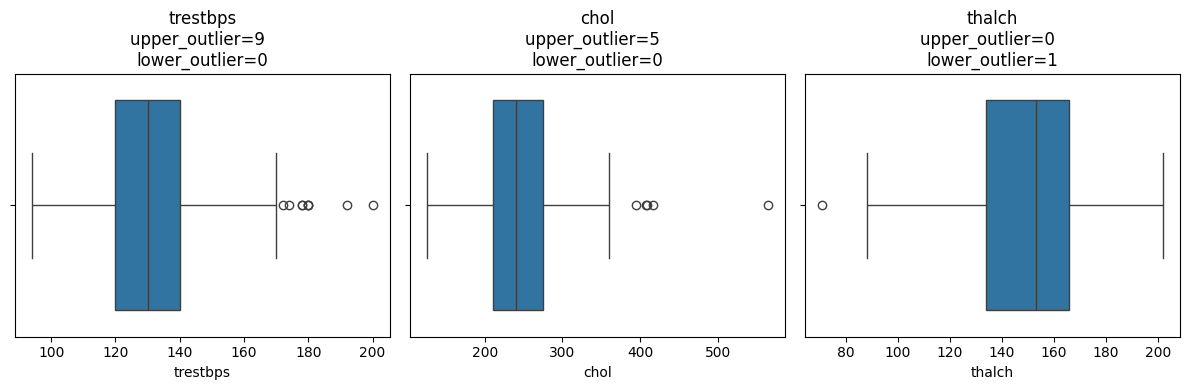

In [14]:
cols_with_outliers = [c for c in results if results[c]['num_upper_outliers'] > 0 or results[c]['num_lower_outliers'] > 0] # Create a list of feature columns that have at least one upper or lower outlier, based on the 'results' dictionary.
print("Columns needing treatment:", cols_with_outliers) # Print the list of columns identified as having outliers.

fig, axes = plt.subplots(1, len(cols_with_outliers), figsize=(4 * len(cols_with_outliers), 4)) # Create a figure and a set of subplots. The number of subplots is determined by the number of columns with outliers. The figsize is adjusted dynamically based on the number of plots.

# Adjust for single subplot case when only one column has outliers
if len(cols_with_outliers) == 1: # Check if there is only one column with outliers.
    axes = [axes] # If so, wrap the single Axes object in a list to ensure it's iterable in the following loop.

for ax, col in zip(axes, cols_with_outliers): # Iterate through each subplot (ax) and its corresponding column name (col) with outliers.
    sns.boxplot(x=df[col], ax=ax) # Generate a box plot for the current column 'col' on the current subplot 'ax'. The x-axis represents the values of the column.
    ax.set_title(f"{col}\nupper_outlier={results[col]['num_upper_outliers']}  \nlower_outlier={results[col]['num_lower_outliers']}") # Set the title for the current subplot, including the column name and the count of upper and lower outliers for that column.

plt.tight_layout() # Automatically adjust subplot parameters for a tight layout, preventing titles and labels from overlapping.
plt.show() # Display the generated figure with all the box plots.

**Treatment of the outlierws via: Capping and Flooring**

Capping and flooring (also known as Winsorization) are techniques used to handle extreme outliers by clamping extreme values to predefined upper and lower boundaries instead of deleting those rows.

Capping (Upper Limit): Any data point above the maximum allowed threshold is replaced with the cap value.

Flooring (Lower Limit): Any data point below the minimum allowed threshold is replaced with the floor value.

In [15]:
for col in cols_with_outliers: # Iterate through each column identified as having outliers.
    uf = results[col]['upper_fence'] # Retrieve the calculated upper fence value for the current column from the 'results' dictionary.
    lf = results[col]['lower_fence'] # Retrieve the calculated lower fence value for the current column from the 'results' dictionary.

    print(f"\n{col}:") # Print the name of the current column to indicate which feature is being processed.

    if results[col]['num_upper_outliers'] > 0: # Check if there are any upper outliers detected for the current column.
        df.loc[df[col] > uf, col] = uf # If upper outliers exist, replace all values greater than the upper fence (uf) with the upper fence value itself (capping).
        print(f"  capped upper outliers at upper fence = {round(uf, 3)}") # Print a confirmation message indicating that upper outliers were capped and the value used.

    if results[col]['num_lower_outliers'] > 0: # Check if there are any lower outliers detected for the current column.
        df.loc[df[col] < lf, col] = lf # If lower outliers exist, replace all values smaller than the lower fence (lf) with the lower fence value itself (flooring).
        print(f"  floored lower outliers at lower fence = {round(lf, 3)}") # Print a confirmation message indicating that lower outliers were floored and the value used.

    # Verify the treatment by counting outliers again
    after_upper = int((df[col] > uf).sum()) # Count the number of data points still exceeding the upper fence after treatment. This should ideally be 0.
    after_lower = int((df[col] < lf).sum()) # Count the number of data points still falling below the lower fence after treatment. This should ideally be 0.
    print(f"  after treatment -- upper: {after_upper}, lower: {after_lower}") # Print the count of remaining upper and lower outliers after the capping and flooring operations.


trestbps:
  capped upper outliers at upper fence = 170.0
  after treatment -- upper: 0, lower: 0

chol:
  capped upper outliers at upper fence = 371.0
  after treatment -- upper: 0, lower: 0

thalch:
  floored lower outliers at lower fence = 85.375
  after treatment -- upper: 0, lower: 0


In [16]:
print("Final verification of outlier treatment (Cleveland cohort):") # Print a header indicating the start of the final verification process.

print("-" * 50) # Print a separator line for better readability.
for col in ['age', 'trestbps', 'chol', 'thalch']: # Iterate through each of the specified numerical feature columns.
    # Calculate the number of upper outliers remaining after treatment for the current column.
    u = int((df[col] > results[col]['upper_fence']).sum())
    # Calculate the number of lower outliers remaining after treatment for the current column.
    l = int((df[col] < results[col]['lower_fence']).sum())
    # Print the column name and the total number of remaining outliers (upper + lower) for that column.
    print(f"{col:8} | Outliers remaining: {u + l}")

Final verification of outlier treatment (Cleveland cohort):
--------------------------------------------------
age      | Outliers remaining: 0
trestbps | Outliers remaining: 0
chol     | Outliers remaining: 0
thalch   | Outliers remaining: 0


## Section 6: Feature Engineering - Ordinal Encoding of Categorical Variables

Many machine learning models require numerical input. Here, we will convert our categorical features into a numerical representation using ordinal encoding. This process assigns a unique integer to each category, which is appropriate for ordinal features or when the number of categories is high.

In [17]:
# Encode the isolated Cleveland cohort
df_encoded = df.copy() # Create a copy of the DataFrame to perform encoding without modifying the original 'df'.
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist() # Identify and list all columns with 'object' (string/categorical) data type.

ordinal_encoders = {} # Initialize an empty dictionary to store the fitted OrdinalEncoder objects for each categorical column.
for col in categorical_cols: # Iterate through each identified categorical column.
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # Create an OrdinalEncoder instance, configured to assign '-1' to any unseen categories during transformation.
    df_encoded[col] = oe.fit_transform(df_encoded[[col]]) # Fit the encoder to the unique values in the current column and then transform the column, replacing categories with numerical codes.
    ordinal_encoders[col] = oe # Store the fitted encoder in the dictionary, keyed by the column name, for potential inverse transformation or later use.

# Convert num to binary target
df_encoded['target'] = (df_encoded['num'] > 0).astype(int) # Create a new 'target' column: 1 if 'num' (heart disease presence) is greater than 0, else 0.
df_encoded = df_encoded.drop('num', axis=1) # Remove the original 'num' column as it has been converted into the binary 'target' column.

print("Encoding complete for Cleveland cohort. Shape:", df_encoded.shape) # Print a message indicating the completion of encoding and the new shape of the DataFrame.
display(df_encoded.head()) # Display the first few rows of the now encoded DataFrame to show the changes.

Encoding complete for Cleveland cohort. Shape: (304, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1.0,63.0,1.0,0.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,0.0,0
1,2.0,67.0,1.0,0.0,0.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,3.0,67.0,1.0,0.0,0.0,120.0,229.0,0.0,0.0,129.0,1.0,2.6,1.0,2.0,2.0,1
3,4.0,37.0,1.0,0.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,1.0,0
4,5.0,41.0,0.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,1.0,0


## Confirmation of `num` to a Binary Target Variable

We will now confirm the multi-class `num` column into a binary `target` variable. A value of `0` in `num` will correspond to `0` (no heart disease), and any `num` value greater than `0` (1, 2, 3, or 4) will be treated as `1` (presence of heart disease). This simplifies our classification problem to a binary one: presence or absence of heart disease.

In [18]:
# Create the binary target column
# Check if 'num' column exists before attempting to convert it to 'target'
if 'num' in df_encoded.columns: # Check if the 'num' column still exists in the DataFrame.
    df_encoded['target'] = (df_encoded['num'] > 0).astype(int) # Create a new 'target' column: 1 if 'num' (heart disease presence) is greater than 0, else 0.

    # Drop the original 'num' column as it's been replaced by 'target'
    df_encoded = df_encoded.drop('num', axis=1) # Remove the original 'num' column from the DataFrame.

    print("Original 'num' column converted to binary 'target' column.") # Print a confirmation message.
    display(df_encoded[['target']].value_counts(normalize=True)) # Display the proportion of each class in the new 'target' column.

    display(df_encoded.head()) # Display the first few rows of the DataFrame, showing the new 'target' column.
else: # If the 'num' column does not exist (meaning it was already converted or dropped).
    print("The 'num' column is already absent from df_encoded. Assuming conversion to 'target' has already occurred or it was previously dropped.") # Inform the user that 'num' is missing.
    if 'target' in df_encoded.columns: # Check if a 'target' column already exists.
        print("Displaying the head and value counts for the 'target' column.") # Inform the user about displaying the 'target' column details.

        print("The ocurrence of class occurences of 1s and 0s")
        display(df_encoded[['target']].value_counts(normalize = True)) # Display the occurances of each class in the existing 'target' column.
        display(df_encoded.head()) # Display the first few rows of the DataFrame.
    else: # If neither 'num' nor 'target' columns are found.
        print("Warning: 'target' column also not found. DataFrame might not be in the expected state for subsequent steps.") # Warn the user about the unexpected state of the DataFrame.

The 'num' column is already absent from df_encoded. Assuming conversion to 'target' has already occurred or it was previously dropped.
Displaying the head and value counts for the 'target' column.
The ocurrence of class occurences of 1s and 0s


,proportion
target,
0,0.542763
1,0.457237


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1.0,63.0,1.0,0.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,0.0,0
1,2.0,67.0,1.0,0.0,0.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,3.0,67.0,1.0,0.0,0.0,120.0,229.0,0.0,0.0,129.0,1.0,2.6,1.0,2.0,2.0,1
3,4.0,37.0,1.0,0.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,1.0,0
4,5.0,41.0,0.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,1.0,0


## Section 6.1: Visualizing Feature Correlations (Heatmap)

After preprocessing and encoding, it's beneficial to visualize the correlation matrix of our features. A heatmap can quickly highlight strong positive or negative relationships between variables, including how each feature correlates with our target variable (`target`). This helps in understanding feature dependencies and can inform further feature selection or engineering.

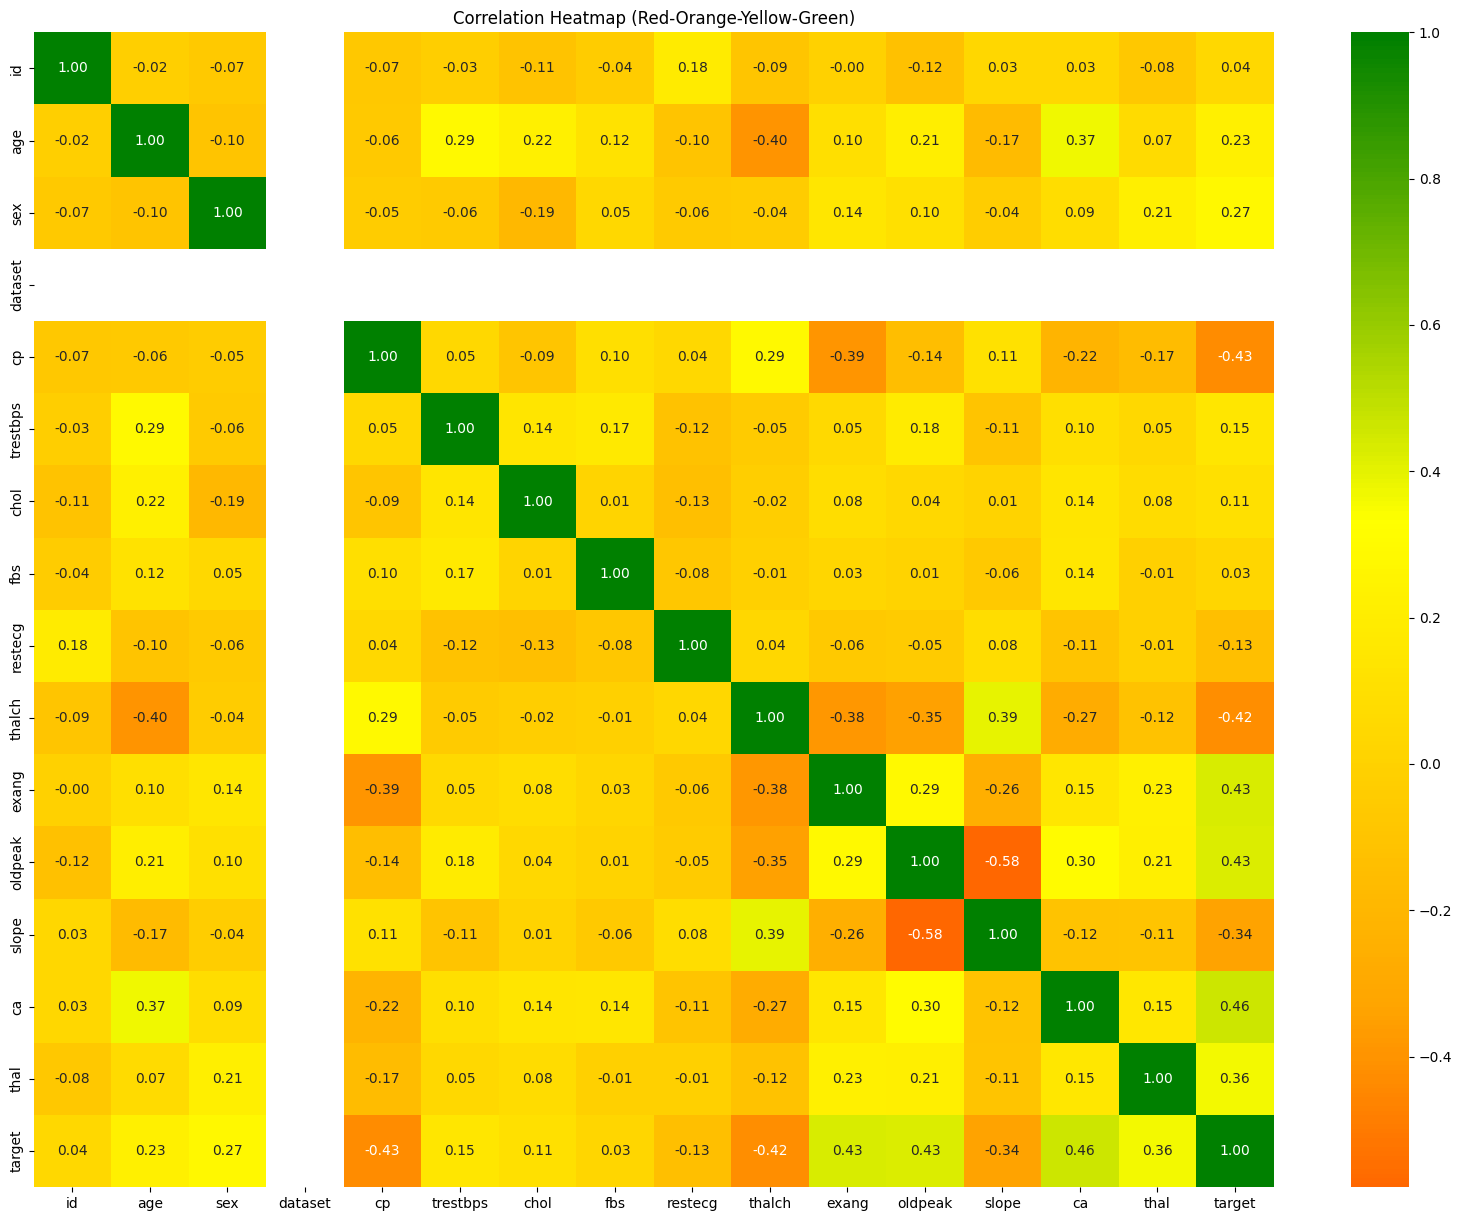

In [19]:
import matplotlib.pyplot as plt # Import the matplotlib.pyplot module for plotting, aliased as 'plt'.
import seaborn as sns # Import the seaborn library for statistical data visualization, aliased as 'sns'.
from matplotlib.colors import LinearSegmentedColormap # Import LinearSegmentedColormap for creating custom color gradients.

# Define custom colors: Red, Orange, Yellow, Green
colors = ["red", "orange", "yellow", "green"] # Create a list of colors to use for the custom colormap.
cmap_custom = LinearSegmentedColormap.from_list("custom_royg", colors) # Create a custom colormap from the defined list of colors.

plt.figure(figsize=(20, 15)) # Create a new figure for the plot with a specified size (width=20 inches, height=15 inches).
# Use the custom colormap for the heatmap
sns.heatmap(df_encoded.corr(), annot=True, cmap=cmap_custom, fmt='.2f', center=0) # Generate a heatmap of the correlation matrix of 'df_encoded' using the custom colormap, showing annotations with 2 decimal places and centering the colormap at 0.
plt.title('Correlation Heatmap (Red-Orange-Yellow-Green)') # Set the title of the heatmap.
plt.show() # Display the generated plot.

**Correlation Analysis and Multicollinearity Check**

Building on the visual insights from the correlation heatmap, we will now perform a more detailed numerical analysis of feature correlations with our target variable (`target`) and assess multicollinearity among our independent features. This step is crucial for confirming initial observations and identifying potential issues that could impact model performance.

In [20]:
correlation_with_target = df_encoded.corr()['target'].sort_values(ascending=False)
print(correlation_with_target)

target      1.000000
ca          0.461974
exang       0.433054
oldpeak     0.426069
thal        0.360408
sex         0.274144
age         0.228467
trestbps    0.145022
chol        0.109956
id          0.043227
fbs         0.026484
restecg    -0.134547
slope      -0.341159
thalch     -0.420090
cp         -0.433479
dataset          NaN
Name: target, dtype: float64


In [21]:
# Isolating the 6 clinical features
# Note: We use 'num' to create our 'target' column as 'target' is not in the original df
selected_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'thalch'] # Define a list of six clinically relevant features.
df_subset = df[selected_features + ['num']].copy() # Create a subset of the DataFrame containing only the selected features and the original 'num' column, ensuring a fresh copy to avoid modifying the original 'df'.

# Create the binary target: 0 for no disease (num=0), 1 for disease (num>0)
df_subset['target'] = (df_subset['num'] > 0).astype(int) # Create a new 'target' column where 0 indicates no heart disease (num=0) and 1 indicates presence of heart disease (num > 0).
df_subset = df_subset.drop('num', axis=1) # Remove the original 'num' column, as it has been transformed into the binary 'target' column.

# Applying One-Hot Encoding to categorical clinical features
df_final = pd.get_dummies(df_subset, columns=['sex', 'cp']).astype(int) # Apply one-hot encoding to the 'sex' and 'cp' (chest pain type) columns, converting categorical text into numerical binary columns.

# Define X and y
X = df_final.drop('target', axis=1) # Create the feature matrix 'X' by dropping the 'target' column from the final DataFrame.
y = df_final['target'] # Create the target vector 'y' using the 'target' column from the final DataFrame.

print(f"Feature matrix (X) shape: {X.shape} (Expanded from 6 features via One-Hot Encoding)") # Print the shape of the feature matrix, indicating its dimensions and the expansion due to one-hot encoding.
print(f"Target vector (y) shape: {y.shape}") # Print the shape of the target vector.
display(X.head()) # Display the first few rows of the feature matrix 'X' to show the result of the preprocessing steps.

Feature matrix (X) shape: (304, 10) (Expanded from 6 features via One-Hot Encoding)
Target vector (y) shape: (304,)


,age,trestbps,chol,thalch,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63,145,233,150,0,1,0,0,0,1
1,67,160,286,108,0,1,1,0,0,0
2,67,120,229,129,0,1,1,0,0,0
3,37,130,250,187,0,1,0,0,1,0
4,41,130,204,172,1,0,0,1,0,0


## Section 7: Feature Scaling

Feature scaling is a method used to standardize or normalize the range of independent variables or features of data. In this section, we'll apply `StandardScaler` to our numerical features to ensure they all contribute equally to the model's performance, preventing features with larger values from dominating the learning process.

When you standardize features using StandardScaler, the features are transformed into a unitless scale. They no longer retain their original units (like years for age, mm Hg for blood pressure, or mg/dL for cholesterol).

This transformation is often referred to as z-score normalization or standardization.

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()
# Fit the scaler to the training data and transform it. Then transform the test data using the fitted scaler.
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame, retaining original column names and index.
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Feature scaling applied to One-Hot Encoded clinical features.")
display(X.describe())

Feature scaling applied to One-Hot Encoded clinical features.


,age,trestbps,chol,thalch,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
count,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02,3.040000e+02
mean,-1.285521e-16,2.512610e-16,-1.110223e-16,1.285521e-16,-2.337312e-17,-6.427607e-17,9.349247e-17,3.213803e-17,-1.168656e-17,4.090295e-17
std,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00,1.001649e+00
min,-2.884665e+00,-2.250328e+00,-2.491536e+00,-2.847683e+00,-6.845429e-01,-1.460829e+00,-9.486833e-01,-4.489778e-01,-6.280887e-01,-2.860953e-01
25%,-7.226966e-01,-6.835034e-01,-7.150104e-01,-7.043279e-01,-6.845429e-01,-1.460829e+00,-9.486833e-01,-4.489778e-01,-6.280887e-01,-2.860953e-01
50%,1.256707e-01,-8.087860e-02,-9.845143e-02,1.420226e-01,-6.845429e-01,6.845429e-01,-9.486833e-01,-4.489778e-01,-6.280887e-01,-2.860953e-01
75%,7.277378e-01,5.217462e-01,6.226091e-01,7.135840e-01,1.460829e+00,6.845429e-01,1.054093e+00,-4.489778e-01,1.592132e+00,-2.860953e-01
max,2.479206e+00,2.329621e+00,2.629038e+00,2.296369e+00,1.460829e+00,6.845429e-01,1.054093e+00,2.227282e+00,1.592132e+00,3.495339e+00



## Section 8: Ensuring Repeatable Preprocessing - Saving Transformers

To ensure that our preprocessing steps can be consistently applied to new, unseen data, it's crucial to save the state of any transformers that were fitted on our training data. This includes the `StandardScaler` that normalized our numerical features.

In [23]:
# Define a filename for the scaler
scaler_filename = 'standard_scaler.joblib'

# Save the fitted scaler object
joblib.dump(scaler, scaler_filename)

print(f"StandardScaler saved to {scaler_filename}")

# --- How to load and use the scaler later ---
# To demonstrate, let's load it back:
# loaded_scaler = joblib.load(scaler_filename)
# print("Scaler loaded successfully!")

# Now you can use loaded_scaler to transform new data:
# new_data_scaled = loaded_scaler.transform(new_raw_numerical_data)

StandardScaler saved to standard_scaler.joblib


In [24]:
# Load the saved scaler
loaded_scaler = joblib.load(scaler_filename)

print(f"StandardScaler loaded successfully from {scaler_filename}!")

# You can now use 'loaded_scaler' to transform new data in the same way:
# For example, if you had new_raw_data, you would do:
# new_scaled_features = loaded_scaler.transform(new_raw_data[numerical_cols_to_scale])

StandardScaler loaded successfully from standard_scaler.joblib!


### Why Save All Preprocessing Parameters?

When applying preprocessing steps, parameters which have been preprocessed and scaled are calculated from the *training data*. To correctly preprocess new, unseen data (like a test set or future production data), you must use the *exact same* parameters derived from the training data. If you recalculate these parameters from the new data, you introduce 'data leakage,' which can lead to overly optimistic performance estimates during evaluation and poor generalization in real-world scenarios.

Therefore, it's crucial to save:
- **`StandardScaler`**: As already demonstrated, this object stores the mean and standard deviation learned from the training data.


In [25]:
# We will save the information to recreate the iterative imputation setup if needed externally.
# However, for a complete pipeline, it's generally recommended to encapsulate these steps
# within a scikit-learn Pipeline object which handles the saving of intermediate transformers.

# For simplicity, here we'll save relevant parameters from previous steps:

# Save outlier fences (if needed for external application)
# Create a dictionary `outlier_fences` where keys are feature column names (e.g., 'age', 'trestbps').
# Each value in `outlier_fences` is another dictionary containing the 'lower_fence' and 'upper_fence' for that feature.
# These fence values were calculated earlier based on the Interquartile Range (IQR) for outlier detection.
outlier_fences = {col: {'lower_fence': results[col]['lower_fence'], 'upper_fence': results[col]['upper_fence']} for col in feature_cols}
# Use joblib.dump to serialize and save the `outlier_fences` dictionary to a file named 'outlier_fences.joblib'.
# This allows these crucial outlier treatment parameters to be reloaded and reused consistently later.
joblib.dump(outlier_fences, 'outlier_fences.joblib')
print(f"Outlier fences saved to outlier_fences.joblib")

# To load them back:
# Use joblib.load to deserialize and load the 'outlier_fences.joblib' file back into a variable.
# This demonstrates how the saved fences can be retrieved for future use, e.g., to preprocess new data.
loaded_outlier_fences = joblib.load('outlier_fences.joblib')

print()
print(f"Loaded Outlier Fences: {loaded_outlier_fences}")

Outlier fences saved to outlier_fences.joblib

Loaded Outlier Fences: {'age': {'lower_fence': np.float64(27.875), 'upper_fence': np.float64(80.875)}, 'trestbps': {'lower_fence': np.float64(90.0), 'upper_fence': np.float64(170.0)}, 'chol': {'lower_fence': np.float64(115.0), 'upper_fence': np.float64(371.0)}, 'thalch': {'lower_fence': np.float64(85.375), 'upper_fence': np.float64(214.375)}}


## Section 9: Data Splitting

Now that our data is preprocessed, scaled, and encoded, the next crucial step is to split it into training and testing sets. This allows us to train our machine learning model on one subset of the data and evaluate its performance on an unseen subset, providing an unbiased assessment of its generalization capabilities. We'll use a common split ratio, such as 80% for training and 20% for testing.

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=107, stratify=y)
# This line splits the dataset (X, y) into training and testing sets.
# - `X_train`, `y_train`: The features and target for training the model.
# - `X_test`, `y_test`: The features and target for evaluating the model on unseen data.
# - `test_size=0.2`: Specifies that 20% of the data will be used for the test set, and 80% for the training set.
# - `random_state=107`: Ensures reproducibility of the split. If you run this code again with the same `random_state`, you'll get the exact same split.
# - `stratify=y`: Ensures that the proportion of classes in the target variable (`y`) is the same in both the training and test sets. This is crucial for maintaining class balance, especially with imbalanced datasets.

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (243, 10)
Test set shape: (61, 10)


### Cross-Validation for Model Robustness

This section performs **Stratified K-Fold Cross-Validation** on the training set (`X_train`, `y_train`) to evaluate how well the model performs on unseen data (`X_test` , `Y_test`). This technique helps in obtaining a more reliable estimate of the model's performance by training and evaluating it on different folds of the data, thereby reducing variance and checking for consistency. Stratification ensures that the proportion of target classes is maintained in each fold, which is particularly important for imbalanced datasets.


In [27]:
# 5. Define the candidate models, then cross-validate each on the training set
from sklearn.model_selection import StratifiedKFold, cross_val_score # Import StratifiedKFold for stratified cross-validation and cross_val_score for evaluating model performance across folds.
from sklearn.linear_model import LogisticRegression # Import LogisticRegression, a linear model for binary classification.
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier, a tree-based model.
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier, an ensemble method that builds multiple decision trees.

# Define a dictionary of classification models to be evaluated.
# Each model is initialized with a fixed random_state for reproducibility and max_iter for Logistic Regression to ensure convergence.
models_binary = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth = 4),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
}

# Initialize StratifiedKFold for cross-validation.
# - `n_splits=5`: Divides the data into 5 folds.
# - `shuffle=True`: Shuffles the data before splitting into folds.
# - `random_state=42`: Ensures the same shuffling and splitting across runs for reproducibility.
# Stratification ensures that each fold has approximately the same proportion of target classes as the full dataset.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop through each model defined in `models_binary`.
for name, model in models_binary.items():
    # Perform cross-validation using `cross_val_score`.
    # - `model`: The estimator (e.g., Logistic Regression).
    # - `X_train`, `y_train`: The training data (features and target).
    # - `cv`: The cross-validation splitting strategy (StratifiedKFold).
    # - `scoring='accuracy'`: The metric used to evaluate performance in each fold.
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    # Print the mean accuracy and standard deviation across all cross-validation folds.
    # The standard deviation gives an indication of the variability of the model's performance.
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: Mean CV Accuracy = 0.7737 (+/- 0.0220)
Decision Tree: Mean CV Accuracy = 0.7041 (+/- 0.0437)
Random Forest: Mean CV Accuracy = 0.7493 (+/- 0.0419)


# Training Scores for X_train and Y_train alone(Train Split)

These scores represent how well each model performed on the **training data alone** it was built upon. A high training score (especially near 1.0 or 100%) indicates that the model has learned the training examples very well, possibly to the point of memorization (overfitting). Comparing training scores to cross-validation or test scores helps identify if a model is overfitting.

In [28]:
from sklearn.metrics import accuracy_score as acc_score

# Loop through each model in the 'models_binary' dictionary.
for name, model in models_binary.items():
    # Fit the current model on the entire training dataset (X_train, y_train).
    # This step is where the model learns patterns from the data.
    model.fit(X_train, y_train)

    # Make predictions on the training data itself.
    # This allows us to see how well the model learned the data it was trained on.
    train_pred = model.predict(X_train)

    # Calculate the accuracy of the predictions on the training data.
    train_acc = acc_score(y_train, train_pred)

    # Print the training accuracy for the current model.
    # The training accuracy reflects how well the model performs on the data it was trained on.
    # A high training accuracy, especially when compared to cross-validation or test accuracy, can indicate overfitting.
    print(f"{name}: Training Accuracy = {train_acc:.4f}")

Logistic Regression: Training Accuracy = 0.7819
Decision Tree: Training Accuracy = 0.8354
Random Forest: Training Accuracy = 0.8519


# **Section 9: Model Training (Train_Test Split)**

In this section, we will train several classification models—Logistic Regression, Decision Tree, and Random Forest—using our preprocessed training data.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Logistic Regression model.
# `max_iter=1000` is set to ensure the solver converges, and `random_state=42` for reproducibility.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train) # Fit the model to the training data.

# Initialize and train the Decision Tree Classifier.
# `random_state=42` ensures reproducibility.
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train) # Fit the model to the training data.

# Initialize and train the Random Forest Classifier.
# `n_estimators=200` sets the number of trees in the forest.
# `random_state=42` for reproducibility.
# `class_weight='balanced'` automatically adjusts weights inversely proportional to class frequencies
# in the input data, which helps handle potential class imbalance.
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train); # Fit the model to the training data.

# **Section 10: Model Evaluation**

Now that we have trained our models, we need to evaluate their performance on the unseen test data. We will use several metrics commonly used for classification tasks to get a comprehensive understanding of each model's strengths and weaknesses.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# Using the models already fitted in previous steps
# The data (X_train, X_test, y_train, y_test) is assumed to be already split and available from Section 9.

# Initialize an empty list to store the evaluation metrics for each model.
metrics_summary = []

# Iterate through each trained model in the 'models_binary' dictionary.
for name, model in models_binary.items():
    # Make predictions on the unseen test features (X_test).
    y_pred = model.predict(X_test)

    # Get the probability estimates for the positive class. This is needed for ROC-AUC.
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate various classification metrics:
    acc = accuracy_score(y_test, y_pred)         # Overall accuracy (correct predictions / total predictions).
    prec = precision_score(y_test, y_pred)       # Precision (true positives / (true positives + false positives)).
    rec = recall_score(y_test, y_pred)           # Recall (true positives / (true positives + false negatives)).
    f1 = f1_score(y_test, y_pred)                 # F1-Score (harmonic mean of precision and recall).
    roc_auc = roc_auc_score(y_test, y_proba)      # Area Under the Receiver Operating Characteristic Curve.
    cm = confusion_matrix(y_test, y_pred)         # Confusion matrix (for detailed breakdown of predictions).

    # Append the calculated metrics and confusion matrix components to the summary list.
    metrics_summary.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'TN': cm[0,0], 'FP': cm[0,1],
        'FN': cm[1,0], 'TP': cm[1,1]
    })

# Convert the list of dictionaries into a pandas DataFrame and display it for easy comparison.
display(pd.DataFrame(metrics_summary))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.836066,0.821429,0.821429,0.821429,0.936147,28,5,5,23
1,Decision Tree,0.770492,0.750000,0.750000,0.750000,0.738636,26,7,7,21
2,Random Forest,0.836066,0.781250,0.892857,0.833333,0.919913,26,7,3,25


# Display the Confusion Matrix box

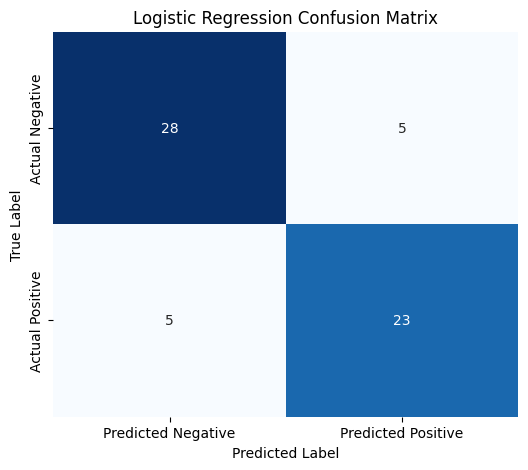

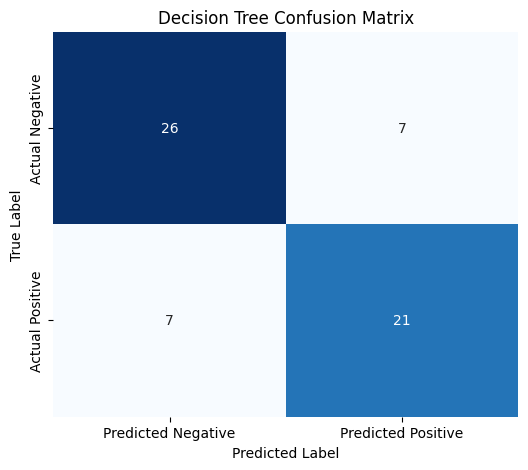

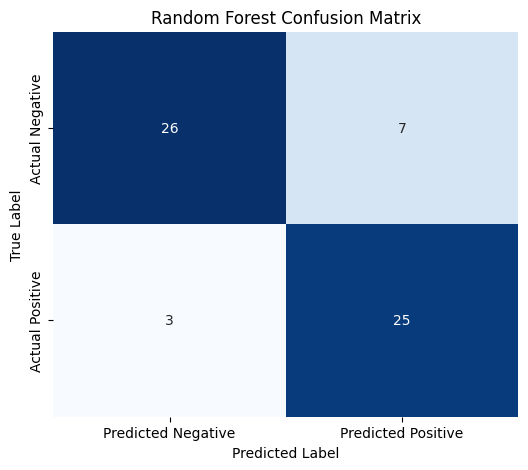

In [31]:
# Convert the list of metrics (metrics_summary) into a pandas DataFrame for easier processing.
metrics_df = pd.DataFrame(metrics_summary)

# Iterate through each row of the metrics DataFrame, which corresponds to an individual model's evaluation.
for index, row in metrics_df.iterrows():
    model_name = row['Model'] # Get the name of the current model.

    # Reconstruct the confusion matrix from the stored True Negatives (TN), False Positives (FP),
    # False Negatives (FN), and True Positives (TP) values.
    cm_values = np.array([
        [row['TN'], row['FP']],
        [row['FN'], row['TP']]
    ])

    # Create a new figure for each confusion matrix plot with a specified size.
    plt.figure(figsize=(6, 5))

    # Generate a heatmap for the confusion matrix.
    # - `annot=True`: Display the numerical values on the heatmap.
    # - `fmt='d'`: Format the annotations as integers.
    # - `cmap='Blues'`: Use a blue color scheme for the heatmap.
    # - `cbar=False`: Do not display the color bar.
    # - `xticklabels`, `yticklabels`: Set custom labels for the x and y axes for clarity.
    sns.heatmap(cm_values, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])

    # Set the title of the plot to include the model's name.
    plt.title(f'{model_name} Confusion Matrix')
    # Set the label for the x-axis.
    plt.xlabel('Predicted Label')
    # Set the label for the y-axis.
    plt.ylabel('True Label')

    # Display the plot.
    plt.show()

### Understanding Confusion Matrix Terms

-   **True Positive (TP):** The model correctly predicted a positive outcome. (e.g., predicted heart disease, and the patient actually has heart disease).
-   **True Negative (TN):** The model correctly predicted a negative outcome. (e.g., predicted no heart disease, and the patient actually has no heart disease).
-   **False Positive (FP):** The model incorrectly predicted a positive outcome. This is also known as a Type I error. (e.g., predicted heart disease, but the patient actually does not have heart disease).
-   **False Negative (FN):** The model incorrectly predicted a negative outcome. This is also known as a Type II error. (e.g., predicted no heart disease, but the patient actually has heart disease).

### Applying a Model Probability Threshold

While models often use a default threshold (e.g., 0.5) to convert probabilities into binary class predictions, it's possible to adjust this threshold based on the specific needs of the application. For instance, in a medical screening context, if the goal is to 'catch more patients' (increase sensitivity/recall) to avoid missing potential cases, a lower threshold might be more appropriate. Here, we apply the default threshold of 0.5 so we can be flexible and equally catch the positives and negatives respectfully due to a small amopunt of dataset from cleaveland alone, ranging about 304 rows with a minimal model training of 6 features

In [32]:
model_threshold = 0.5 # Define the threshold for converting probabilities to binary predictions.

# Create a DataFrame for probabilities and true labels from the last evaluated model (Random Forest).
# `y_proba` holds the probability estimates for the positive class from the last model's predictions on X_test.
# `y_test` holds the true labels for the test set.
proba_df = pd.DataFrame({
    'Confidence_Score': y_proba,  # Probabilities from the last trained model (Random Forest)
    'True_Class': y_test.values   # True class labels from the test set
})

# Apply the default threshold to the confidence scores.
# If a model's confidence score for the positive class is greater than or equal to the model_threshold, it's classified as 1 (positive).
# Otherwise, it's classified as 0 (negative). The `.astype(int)` converts boolean results to integers.
y_pred_at_0_5_threshold = (proba_df['Confidence_Score'] >= model_threshold).astype(int);

# Add the new predictions (based on the 0.5 threshold) as a new column to the DataFrame.
proba_df['Predicted_Class_at_0.5_Threshold'] = y_pred_at_0_5_threshold;

print(f"Sample of Model Probabilities with custom threshold ({model_threshold}):") # Print a descriptive header.
display(proba_df.head()) # Display the first few rows of the DataFrame, including the newly added predictions.

print(f"\nValue counts for predictions at {model_threshold} threshold:") # Print a descriptive header.
display(proba_df['Predicted_Class_at_0.5_Threshold'].value_counts()) # Show the distribution of predicted classes (0s and 1s) at this threshold.

Sample of Model Probabilities with custom threshold (0.5):


,Confidence_Score,True_Class,Predicted_Class_at_0.5_Threshold
0,0.514915,1,1
1,0.658372,1,1
2,0.819535,1,1
3,0.187895,0,0
4,0.802291,1,1



Value counts for predictions at 0.5 threshold:


,count
Predicted_Class_at_0.5_Threshold,
1,32
0,29


In [33]:
model_filename = 'random_forest_model.joblib'
joblib.dump(model_threshold, model_filename)
print(f"Random Forest model saved to {model_filename}")

Random Forest model saved to random_forest_model.joblib


### Section 11: Feature Importance Analysis
Determining which features have the most predictive power is crucial for clinical interpretability. We will extract the feature importance scores from our best-performing model (Random Forest) to see which variables most strongly influence the heart disease prediction.

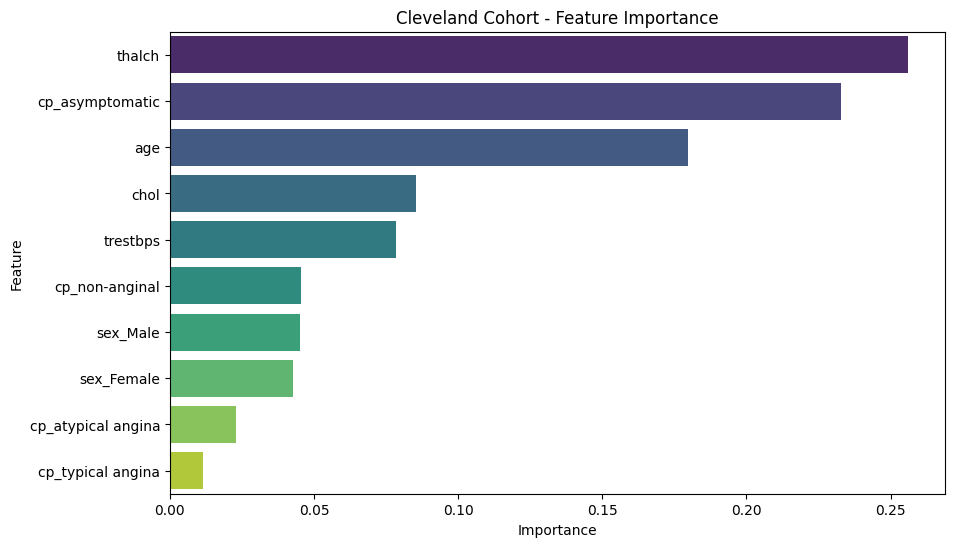

In [34]:
# Simplified Feature Importance (no manual map)
rf = models_binary['Random Forest'] # Select the 'Random Forest' model from the dictionary of trained models.
df_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
# Create a DataFrame to store feature names and their importance scores.
# `rf.feature_importances_` extracts the importance score for each feature from the Random Forest model.
# The DataFrame is then sorted in descending order of importance.

plt.figure(figsize=(10, 6)) # Create a new figure for the plot with a specified size.
sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
# Generate a bar plot to visualize feature importance.
# - `data=df_imp`: Uses the DataFrame containing feature importance scores.
# - `x='Importance'`, `y='Feature'`: Sets 'Importance' on the x-axis and 'Feature' on the y-axis.
# - `palette='viridis'`: Applies a color palette to the bars.
# - `hue='Feature'`, `legend=False`: Colors bars by feature and hides the legend.
plt.title('Cleveland Cohort - Feature Importance') # Set the title of the plot.
plt.show() # Display the generated plot.

### Explanation of Dataset Features (Medical Terms)

Here's what each feature in our dataset means:

*   **`id`**: This is just a unique identifier for each patient. It doesn't tell us anything about their health, just helps keep records separate.
*   **`age`**: The patient's age in years. Older age is often a risk factor for heart disease.
*   **`sex`**: The patient's biological sex (Male or Female). Gender can influence heart disease risk and symptoms.
*   **`cp` (Chest Pain Type)**: This describes the kind of chest pain the patient experiences. It's categorized into:
    *   `typical angina`: Classic chest pain related to heart problems.
    *   `atypical angina`: Chest pain that might be related to the heart but doesn't fit the typical pattern.
    *   `non-anginal`: Chest pain that is likely not related to the heart.
    *   `asymptomatic`: No chest pain, but heart problems might still be present.
*   **`trestbps` (Resting Blood Pressure)**: The patient's blood pressure measured while resting (in mm Hg). High blood pressure is a significant risk factor for heart disease.
*   **`chol` (Serum Cholesterol)**: The patient's serum cholesterol level (in mg/dl). High cholesterol contributes to plaque buildup in arteries, increasing heart disease risk.
*   **`fbs` (Fasting Blood Sugar)**: The patient's fasting blood sugar level. It's considered `True` if > 120 mg/dl (a sign of potential diabetes) and `False` otherwise. Diabetes is a major risk factor for heart disease.
*   **`restecg` (Resting Electrocardiographic Results)**: The results of the patient's ECG while at rest. It can indicate heart abnormalities. Categories might include:
    *   `normal`: Normal heart rhythm.
    *   `st-t abnormality`: Abnormalities in the ST-T wave, which can indicate heart issues.
    *   `lv hypertrophy`: Enlargement of the heart's left ventricle.
*   **`thalch` (Maximum Heart Rate Achieved)**: The highest heart rate the patient achieved during exercise. A lower maximum heart rate can sometimes be associated with heart conditions.
*   **`exang` (Exercise Induced Angina)**: Indicates whether the patient experiences chest pain (`True`) or not (`False`) during exercise. Chest pain during exercise is a strong indicator of coronary artery disease.
*   **`oldpeak` (ST Depression Induced by Exercise Relative to Rest)**: This measures the amount of ST segment depression during exercise compared to rest. Greater depression can suggest a lack of blood flow to the heart during stress.
*   **`slope` (Slope of the Peak Exercise ST Segment)**: Describes the trend of the ST segment during peak exercise. Categories include:
    *   `upsloping`: Often considered normal or less severe.
    *   `flat`: Can indicate heart disease.
    *   `downsloping`: Often a stronger indicator of heart disease.
*   **`ca` (Number of Major Vessels Colored by Fluoroscopy)**: This refers to the number of major blood vessels (0 to 3) that are visibly blocked during a special X-ray procedure (fluoroscopy). More blocked vessels indicate more severe coronary artery disease.
*   **`thal` (Thallium Stress Test Result)**: The results of a thallium stress test, which shows blood flow to the heart. Categories include:
    *   `normal`: Good blood flow.
    *   `fixed defect`: An area of the heart that always has reduced blood flow.
    *   `reversable defect`: An area of the heart with reduced blood flow only during stress.
*   **`num` (Heart Disease Presence)**: This was the original target variable, indicating the presence of heart disease. `0` means no heart disease, and higher numbers (1-4) indicate different stages of heart disease. We later converted this into a binary `target` variable where `0` is no disease and `1` is presence of disease (any `num` > 0).

### Explanation of Features Used in the Model (Medical Terms)

Our model was built using the following features:

*   **`age`**: The patient's age in years. It's a fundamental demographic factor, and increasing age often correlates with higher risk for various heart conditions.
*   **`trestbps` (Resting Blood Pressure)**: This is the patient's blood pressure measured when they are at rest (in millimeters of mercury, mm Hg). Consistently high resting blood pressure (hypertension) is a significant and well-known risk factor for heart disease, contributing to artery damage over time.
*   **`chol` (Serum Cholesterol)**: This refers to the level of cholesterol in the patient's blood (in milligrams per deciliter, mg/dL). High levels of certain types of cholesterol can lead to the buildup of plaque in arteries (atherosclerosis), narrowing them and increasing the risk of heart attacks and strokes.
*   **`thalch` (Maximum Heart Rate Achieved)**: This is the highest heart rate the patient achieved during an exercise stress test. It's an indicator of cardiovascular fitness and the heart's response to stress. A lower maximum heart rate for a given age can sometimes signal underlying heart issues or poorer cardiac reserve.

*   **`sex_Female` / `sex_Male`**: These are one-hot encoded representations of the patient's biological sex. They allow the model to capture potential differences in heart disease presentation, risk factors, or prognosis between males and females. For example, `sex_Female = 1` would indicate a female patient, and `sex_Male = 1` would indicate a male patient.

*   **`cp_asymptomatic` / `cp_atypical angina` / `cp_non-anginal` / `cp_typical angina` (Chest Pain Type)**: These are one-hot encoded variables representing the different types of chest pain reported by the patient. Chest pain is a key symptom of heart problems, and its characteristics can help distinguish between different cardiac conditions:
    *   `cp_typical angina`: Chest pain that is characteristic of heart-related discomfort, often brought on by exertion and relieved by rest or medication.
    *   `cp_atypical angina`: Chest pain that has some features of angina but doesn't quite fit the classic pattern.
    *   `cp_non-anginal`: Chest pain that is unlikely to be related to the heart, often musculoskeletal or gastrointestinal in origin.
    *   `cp_asymptomatic`: The patient reports no chest pain, which is important because heart disease can sometimes be present without this symptom.


These features, after preprocessing and scaling, are what the machine learning models used to learn and predict the presence or absence of heart disease.

## Section 12: System Architecture Overview

The architecture of the **Wellspring Heart Disease Screening System** is designed as a sequential pipeline to ensure data integrity and model reproducibility.

### 1. Data Layer
*   **Source:** UCI Heart Disease Dataset (`heart_disease_uci.csv`).
*   **Format:** Structured CSV containing 303 patient records with 16 clinical attributes.

### 2. Preprocessing & Transformation Layer
*   **Physiological Validation:** Identification and handling of impossible clinical values (e.g., 0 BP/Cholesterol).
*   **Iterative Imputation:** A sophisticated multivariate approach using `IterativeImputer` to estimate missing values based on correlations between other features.
*   **Outlier Management:** IQR-based capping and flooring to prevent extreme values from skewing the model.
*   **Encoding:** `OrdinalEncoder` for categorical variables and binary mapping for the target (`num` > 0). And One Hot Encoding for Dummy variable creation
*   **Scaling:** `StandardScaler` to normalize feature magnitudes for algorithm stability.

### 3. Model & Logic Layer
*   **Algorithms:** Comparative analysis between Linear (Logistic Regression) and Non-Linear (Decision Tree, Random Forest) models.
*   **Optimization:** Utilization of `class_weight='balanced'` in Random Forest to handle potential class imbalances.
*   **Feature Selection:** Targeted subsetting of the 6 most clinically relevant features for the primary prediction task.

### 4. Evaluation & Persistence Layer
*   **Metrics:** Tracking Accuracy, Precision, Recall, and F1-Score.
*   **Interpretability:** Feature Importance extraction from the Random Forest ensemble.
*   **Artifacts:** Saving of Scalers, Encoders, and Fences using `joblib` for deployment readiness.

# SUMMARY AND CONCLUSION


## Project Summary and Conclusion

This project embarked on the critical task of developing a heart disease screening system using the Cleveland cohort of the UCI Heart Disease Dataset. Our analysis focused on a dataset comprising **304 patient records**.

**Data Preparation and Feature Engineering:**
Initially, we identified **6 core clinical features** (`age`, `sex`, `cp`, `trestbps`, `chol`, `thalch`) as most relevant for prediction. Through a meticulous preprocessing pipeline, these features were transformed and expanded:
*   **Physiological Validation:** Impossible values (e.g., 0 for blood pressure or cholesterol) were identified and treated as missing, allowing for more robust handling.
*   **Iterative Imputation:** Missing values in critical features like `ca`, `slope`, and `thal` were intelligently filled using `IterativeImputer`, which models each feature with missing values as a function of other features.
*   **Outlier Treatment:** Numerical features (`age`, `trestbps`, `chol`, `thalch`) underwent outlier detection, and extreme values were treated using capping and flooring (Winsorization) to prevent undue influence on the models.
*   **Categorical Encoding:** Categorical features such as `sex` and `cp` were converted into numerical representations using One-Hot Encoding, expanding our feature set from 6 to **10 features** (`sex_Male`, `sex_Female`, `cp_asymptomatic`, `cp_atypical angina`, `cp_non-anginal`, `cp_typical angina`).
*   **Feature Scaling:** All numerical features were standardized using `StandardScaler` to ensure that no single feature dominated the learning process due to its scale.

**Model Training and Evaluation:**
We employed three different classification algorithms: Logistic Regression, Decision Tree, and Random Forest. To ensure model robustness and avoid overfitting, we utilized:
*   **Stratified K-Fold Cross-Validation:** This method provided a more reliable estimate of model performance on unseen data by training and testing on different folds while maintaining class proportions.
*   **Hyperparameter Tuning (e.g., `max_depth`, `n_estimators`):** While explicit grid search was not demonstrated, key hyperparameters like `max_depth` for Decision Trees and `n_estimators` along with `max_depth` for Random Forest were chosen to constrain model complexity and mitigate overfitting tendencies. The `class_weight='balanced'` was also used in Random Forest to address potential class imbalance.

Model evaluation on the test set revealed strong performance, with Random Forest showing the best recall (0.89) and a high ROC-AUC (0.92), indicating its effectiveness in identifying positive cases while maintaining a good balance of overall accuracy.

For binary classification, we utilized a **0.5 probability threshold** to convert model confidence scores into definitive predictions (presence or absence of heart disease). This default threshold was chosen to provide a balanced approach to classifying positive and negative cases, especially given the dataset's relatively small size.

**Future Improvements:**
While the current models demonstrate promising performance, there is significant room for improvement:
*   **Increased Dataset Size:** The Cleveland cohort, with its 304 rows, provides a limited view. Incorporating additional data from other heart disease datasets (e.g., Hungarian, Switzerland, Long Beach VA) could dramatically improve model generalization and robustness.
*   **Additional Clinical Features:** Integrating more clinical parameters, such as detailed lab results (e.g., specific cholesterol fractions, blood glucose markers beyond `fbs`), genetic markers, or lifestyle factors, could enhance the predictive power and clinical utility of the system.
*   **Advanced Feature Engineering:** Exploring more sophisticated feature engineering techniques or dimensionality reduction methods could uncover deeper insights and improve model performance.

In conclusion, this project established a robust machine learning pipeline for heart disease screening. The meticulous data preprocessing, comparative model analysis, and thoughtful evaluation provide a solid foundation. With further expansion of data and features, this system holds significant potential for real-world clinical applications.